# 1. 导入所需要的库

In [11]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# 2. 读取数据，对初始数据进行处理
## 读取数据，前8列为x，最后一列为y

In [12]:
data = pd.read_csv('Concrete_Data_Yeh.csv')
x = data.iloc[:, :-1].values
y = data.iloc[:, -1].values.reshape(-1, 1)

## 划分80%训练集20%测试集,设置可重复的随机过程

In [13]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)  #test_size为20%，random_state表示为设置可重复的随机过程

## 对每一列数据进行数据标准化，$\frac{x-x_{mean}}{\sigma}$

In [14]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
#转换为PyTorch向量
X_train = torch.tensor(x_train, dtype=torch.float32)
X_test  = torch.tensor(x_test, dtype=torch.float32)
Y_train = torch.tensor(y_train, dtype=torch.float32)
Y_test  = torch.tensor(y_test, dtype=torch.float32)

# 2. 构建神经网络以及损失函数
## 定义神经网络8---->64---->32---->1，网络使用了ReLU激活函数

In [15]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(8, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.model(x)
model = Net()


## 定义损失函数用均方误差MSE，优化器用Adam

In [16]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001) #自适应学习率设置为0.001

# 3. 开始进行网络训练，epochs=20000

In [17]:
epochs = 20000
loss_list = []

#开始训练
for epoch in range(epochs):
    model.train()                         #进入训练模式，开启dropout等

    outputs = model(X_train)              #训练数据的输出值
    loss = criterion(outputs, Y_train)    #计算输出至与真实值对比下的损失函数

    optimizer.zero_grad()                 #初始化梯度（归零)
    loss.backward()                       #反向传输计算当前loss对各参数的梯度
    optimizer.step()                      #通过梯度下降优化参数

    loss_list.append(loss.item())         #记录当前loss

    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

model.eval()                              #进入测试模式，关闭 dropout

with torch.no_grad():                    
    Y_pred = model(X_test)                #用测试集进行预测


Epoch [100/20000], Loss: 796.2184
Epoch [200/20000], Loss: 187.9733
Epoch [300/20000], Loss: 157.0961
Epoch [400/20000], Loss: 137.1472
Epoch [500/20000], Loss: 118.7512
Epoch [600/20000], Loss: 102.0438
Epoch [700/20000], Loss: 88.0190
Epoch [800/20000], Loss: 76.2228
Epoch [900/20000], Loss: 65.2656
Epoch [1000/20000], Loss: 54.7893
Epoch [1100/20000], Loss: 43.0448
Epoch [1200/20000], Loss: 35.6458
Epoch [1300/20000], Loss: 30.6237
Epoch [1400/20000], Loss: 27.2965
Epoch [1500/20000], Loss: 24.7561
Epoch [1600/20000], Loss: 22.6647
Epoch [1700/20000], Loss: 20.8556
Epoch [1800/20000], Loss: 19.2435
Epoch [1900/20000], Loss: 17.8692
Epoch [2000/20000], Loss: 16.6370
Epoch [2100/20000], Loss: 15.5469
Epoch [2200/20000], Loss: 14.5596
Epoch [2300/20000], Loss: 13.6363
Epoch [2400/20000], Loss: 12.7985
Epoch [2500/20000], Loss: 12.1042
Epoch [2600/20000], Loss: 11.4924
Epoch [2700/20000], Loss: 10.9201
Epoch [2800/20000], Loss: 10.3857
Epoch [2900/20000], Loss: 9.8809
Epoch [3000/20000]

# 3. 开始进行网络训练，epochs=20000

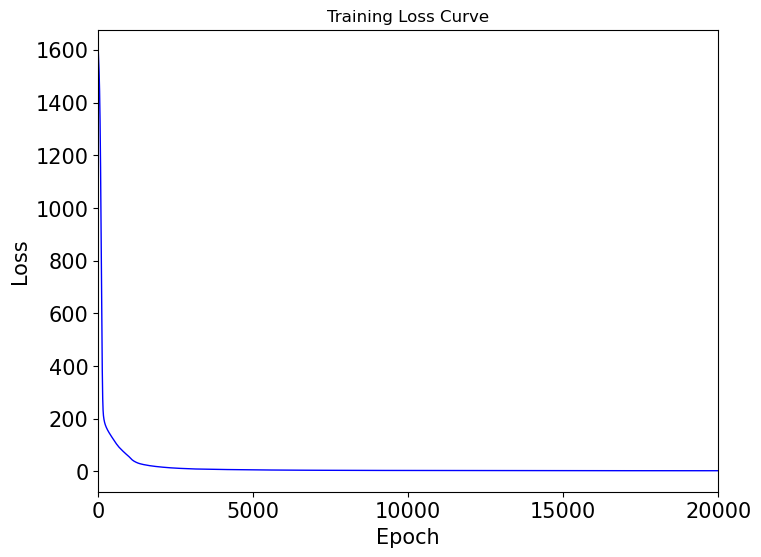

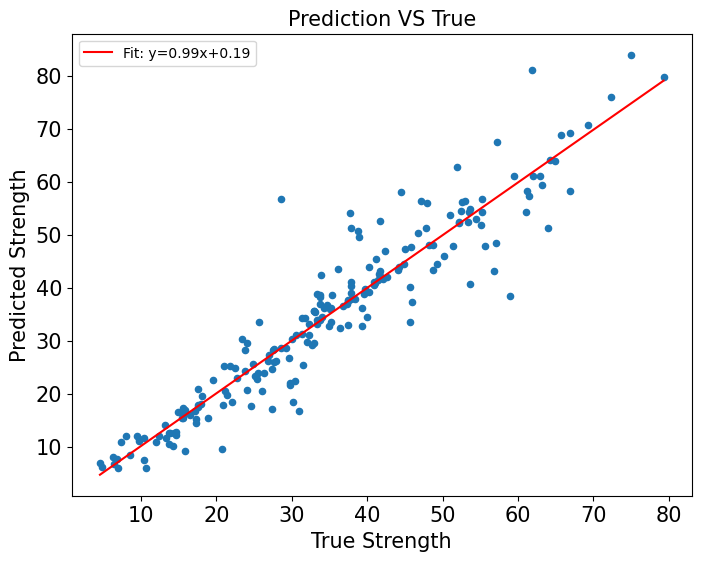

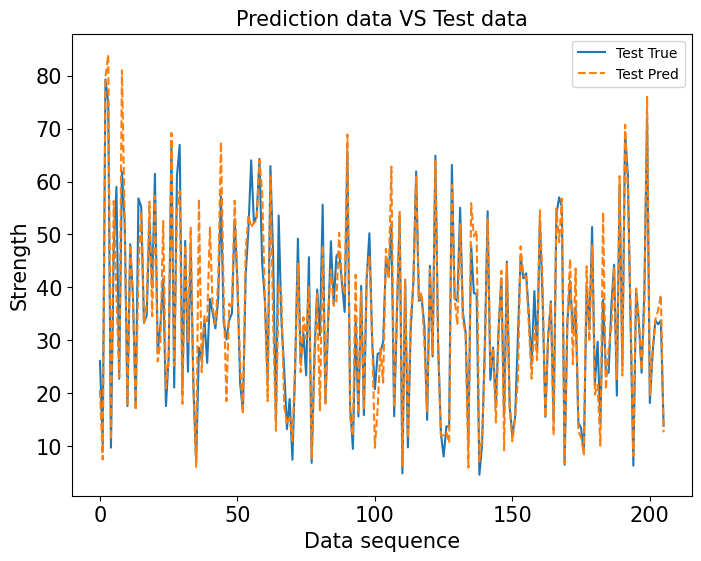


Test MSE: 30.0292


In [18]:
# （1）损失曲线
plt.figure(figsize=(8,6))
plt.plot(loss_list, color='blue', linewidth=1)
plt.xlabel("Epoch", fontsize=15)
plt.ylabel("Loss", fontsize=15)
plt.title("Training Loss Curve")
plt.xlim(0,20000)
plt.xticks([0, 5000, 10000, 15000, 20000], fontsize=15)
plt.yticks(fontsize=15)
plt.show()


# （2）预测 vs 真实
k, b = np.polyfit(Y_test.detach().numpy().flatten(), Y_pred.detach().numpy().flatten(), 1)
x_line = np.linspace(min(Y_test.detach().numpy().flatten()), max(Y_test.detach().numpy().flatten()), 1000)
y_line = k * x_line + b

plt.figure(figsize=(8,6))
plt.scatter(Y_test.detach().numpy(), Y_pred.detach().numpy(), s=20)
plt.plot(x_line, y_line, 'r', label=f"Fit: y={k:.2f}x+{b:.2f}")
plt.xlabel("True Strength", fontsize=15)
plt.ylabel("Predicted Strength", fontsize=15)
plt.title("Prediction VS True", fontsize=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.legend()
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(Y_test.detach().numpy(), label="Test True")
plt.plot(Y_pred.detach().numpy(), '--', label="Test Pred")
plt.legend()
plt.xlabel("Data sequence", fontsize=15)
plt.ylabel("Strength", fontsize=15)
plt.title("Prediction data VS Test data", fontsize=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()

mse = mean_squared_error(Y_test.detach().numpy(), Y_pred.detach().numpy())     #计算MSE
print("\nTest MSE:", mse)